In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import datetime
import plotly.express as px

### 1. 
Проанализируйте количество преступлений по отдельности от времени дня, дня недели, 
месяца в среднем за весь период и год к году. Сделайте выводы

In [2]:
df = pd.read_csv('crime.csv', index_col=0)

In [3]:
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['year'] = df['DATE OCC'].apply(lambda x: x.year)
df['month'] = df['DATE OCC'].apply(lambda x: x.month)
df['day of week'] = df['DATE OCC'].apply(lambda x: x.day_name())
df['hour'] = df['TIME OCC'] // 100
display(df.head())

#display(df['DATE OCC'].info()) #проверила на NA, нет
#df['TIME OCC'].info()

,DR_NO,DATE OCC,TIME OCC,AREA NAME,Rpt Dist No,Vict Age,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status Desc,LOCATION,Cross Street,LAT,LON,year,month,day of week,hour
0,200106753,2020-02-08,1800,Central,182,47,M,O,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,Invest Cont,1000 S FLOWER ST,NaN,34.0444,-118.2628,2020,2,Saturday,18
1,200907217,2020-03-10,2037,Van Nuys,964,19,M,O,CLOTHING STORE,NaN,Invest Cont,14000 RIVERSIDE DR,NaN,34.1576,-118.4387,2020,3,Tuesday,20
2,200406391,2020-03-01,1430,Hollenbeck,407,27,M,W,PUBLIC STORAGE,NaN,Invest Cont,4500 HUNTINGTON DR,NaN,34.0881,-118.1877,2020,3,Sunday,14
3,200606074,2020-02-07,1615,Hollywood,646,23,F,H,STREET,NaN,Adult Arrest,HOLLYWOOD,MC CADDEN,34.1016,-118.3370,2020,2,Friday,16
4,201000767,2020-07-13,2000,West Valley,1043,41,M,W,PARKING LOT,NaN,Adult Arrest,18600 HATTERAS ST,NaN,34.1774,-118.5387,2020,7,Monday,20


In [4]:
#количество преступлений по отдельности от времени дня в среднем за весь период
def period(hour):
    if 5 <= hour < 11: #я логически поделила утро/день/вечер/ночь по привычкам людей, но чтобы было равномерно по 6 часов
        return 'Morning'
    elif 11 <= hour < 17:
        return 'Day'
    elif 17 <= hour < 23:
        return 'Evening'
    else:
        return 'Night'
df['time period'] = df['hour'].apply(period)
df['time period'] = pd.Categorical(df['time period'], categories=['Night', 'Morning','Day','Evening'], ordered=True)

In [5]:
period_counts = df.groupby('time period', observed=False).size()
period_counts

time period
Night      130382
Morning    134556
Day        231307
Evening    228450
dtype: int64

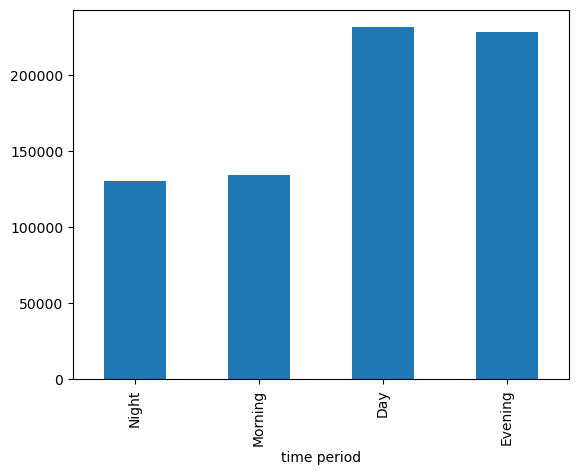

In [6]:
period_counts.plot(kind='bar');

Больше всего преступлений совершается днем и вечером, когда люди работают/учатся/посещают общественные места, то есть экономически и социально активны. Также думаю влияет, что днем чаще регистрируют официально дело в полиции, чем ночью. Нет колонки для оценки легкой/средней/тяжкой степени преступления (виды преступлений было бы очень интересно не по месту преступления). Если было бы больше легких/средних преступлений по типу краж/вандализма/драк, то весьма логично, что наибольшее количество днем-вечером

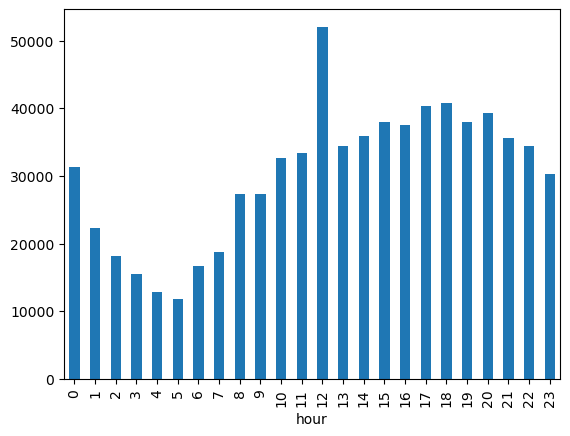

In [7]:
a = df.groupby('hour', observed=False).size()
a.plot(kind='bar'); #стало интресно глянуть по часам, потому что я была уверена что ночью будет много преступлений

Cмущает пик в 12 часов. Погуглила про спецефику оформления в США
Предположения:
- AM/PM Confusion(Путают полночь/полдень): When typing a report into a computer, officers or victims often confuse "12:00 AM" (midnight) with "12:00 PM" (noon). This accidentally shifts unknown nighttime crimes into the middle of the day.Lunch 
- Break Reporting (Обнаруживают во время перерывов/ланчей): Many people only discover a crime (like a stolen package, a vandalized car, or an office theft) during their lunch break. Police then log 12:00 PM as the time the incident was officially reported.
- Residential Burglaries/Empty Houses(по статистике часто кражи в домах днем пока люди не дома): Most home break-ins happen between 10:00 AM and 3:00 PM. Criminals target neighborhoods at noon because they know residents are at work, school, or out getting lunch. (https://www.vivint.com/resources/article/when-does-crime-occur-most)

То, что с полночи наичнается снижаться уровень преступности, предполагаю, что о них реже заявляют, и регистрация уже чаще происходит утром-днем (тоже будто одна из причин почему в 12 дня резкий скачок). Плюс преступления тяжкие, и прохожих на улицах сильно меньше,то есть свидетели редко могут заявить, как например днем. 

Также если бы был столбец видов преступлений, можно было бы визуализировать, что тяжких преступлений меньше и гипотеза: поэтому ночью снижение.А днем частые для америки кражи, вандализм намного легче в реализации и потому их совершается очень много и в основном днем

day of week
Monday       102266
Tuesday       99006
Wednesday    102250
Thursday     101797
Friday       109584
Saturday     107597
Sunday       102195
dtype: int64

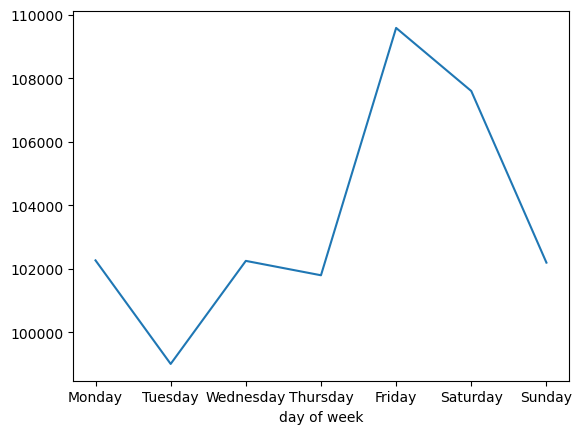

In [8]:
#количество преступлений по отдельности от дня недели в среднем за весь период
week = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day of week'] = pd.Categorical(df['day of week'], categories=week, ordered=True)
week_counts = df.groupby('day of week', observed=False).size()
display(week_counts)
week_counts.plot(); #bar не очень удачно показывает разницу между неделями

Меньше всего преступлений по вторникам, больше всего по пятницам-субботам. В течение будней примерно одинаковое число преступлений, начиная с выходных растет, предположения:
- люди на выходных могут гулять, чаще контактировать с другими людбми, проводится больше мероприятия
- алкоголь, часто именно в выходные посещаются бары/клубы, это может влиять на более частое агрессивное поведение людей и появление конфликтов/драк/пьяного вождения
https://www.eurekalert.org/news-releases/565204

К воскресенью уже многие начинают готовиться к рабочей неделе, поэтому большинство проводит это как "домашний день", (до ночи не погуляешь перед тем, как утром рано вставать на работу). Многие проводят этот день с семьей. Также нашла информацию, что в некоторых штатах в этот день ограничения на продажу алкоголя.Также часто в США воскркесенье - день посещения церкви
https://pmc.ncbi.nlm.nih.gov/articles/PMC3224020/


month
1     68156
2     63966
3     64251
4     60470
5     59509
6     58161
7     60272
8     59673
9     57816
10    60088
11    56083
12    56250
dtype: int64

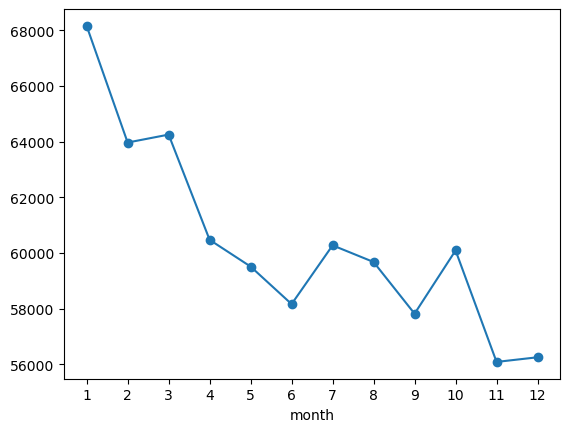

In [9]:
#количество преступлений по отдельности от месяца в среднем за весь период
month_counts = df.groupby('month', observed=False).size()
display(month_counts)
month_counts.plot(marker='o');

plt.xticks(range(1,13));

Самый максимум в январе, затем постепенно снижается и в декабре самое минимальное. Предполагаю, что из-за того что в 2025 году практически не даны данные по месяцам, но по итогу там практически нет данных вовсе за 25 год, поэтому не в этом причина

In [10]:
pd.crosstab(df['year'], df['month']) #Проверила почему все месяца меньше именно за 2025 год (предположение было что мало данных)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,14618,13574,12246,11515,12498,12418,12745,12637,11838,12258,11689,11809
2021,12328,11407,12341,12137,12962,13046,14406,13916,13896,14423,13670,13158
2022,13686,13374,14841,14905,15265,15332,14987,15156,14648,15393,13952,15144
2023,14778,13785,13910,13408,13643,13574,14377,14280,13637,14181,13114,13266
2024,12717,11786,10885,8505,5141,3791,3757,3684,3797,3833,3658,2873
2025,29,40,28,0,0,0,0,0,0,0,0,0


Действительно, подтвердилось, что данные почти отсутствуют, но еще можно отметить что начиная с 4-5  месяца преступлений 
сильно меньше, возможно данные за вторуб половину 2024 года неполные. К концу 24 года по 2-3 тысячи престулпний, xто очень мало по
 сравнению с другими годами. Поэтому на графике 2-ая половина года резко снижается и в декабре особенно минимум

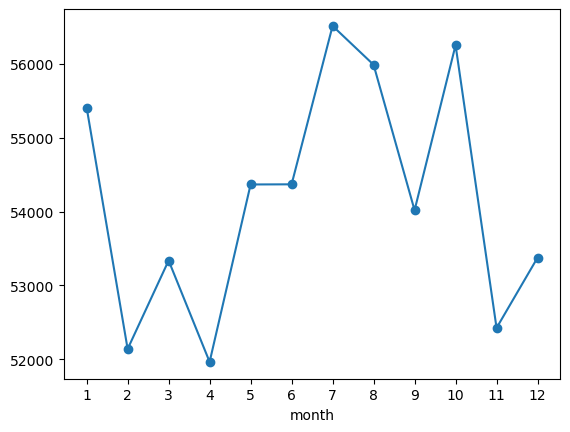

In [11]:
df_full = df[df['year'].isin([2020, 2021, 2022, 2023])] #для точности смотрим без неполных годов 2024/2025
month_counts_clean = df_full.groupby('month').size()

month_counts_clean.plot(marker='o');
plt.xticks(range(1,13));

Теперь сезонные пики в январе, июле-августе, октябре. Это логично так как в январе новогодние праздники (кстати к декабрю тоже начинается рост преступности), летом люди чаще посещают разные места,уезжают в отпуск,путешествуют, много приезжих. В октябре хелуин, в начале ноября день благодарения.

time period,Night,Morning,Day,Evening
year,,,,
2020,26267,26357,48500,48721
2021,28116,28801,50700,50073
2022,33265,34963,56001,52454
2023,29724,31278,52347,52604
2024,13006,13132,23700,24589
2025,4,25,59,9


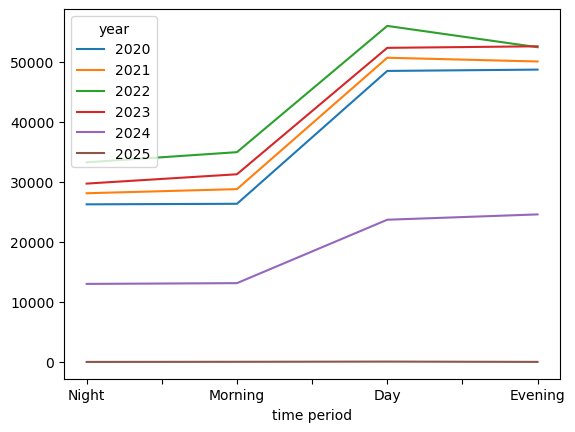

In [12]:
#количество преступлений по отдельности от времени дня в среднем год к году
period_countY = df.groupby(['year', 'time period'], observed= False).size().unstack()
display(period_countY)
period_countY.T.plot();

Так как я уже ранее смотреоа, что данных по 2024/2025 году сильно меньше чем за другие годы, то очевидно почему линии этих годов сильно ниже. 2020-2023 тенденция одинакова: ночью мало, с утра растет и уже днем-вечером много преступлений. Наиболее криминально активный 2022 год

day of week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
year,,,,,,,
2020,21190,20710,21876,21216,22164,21830,20859
2021,23075,21325,22013,21892,23936,22993,22456
2022,24295,24164,24713,24956,27070,26769,24716
2023,23253,22620,23307,23201,24921,24659,23992
2024,10438,10176,10318,10514,11469,11344,10168
2025,15,11,23,18,24,2,4


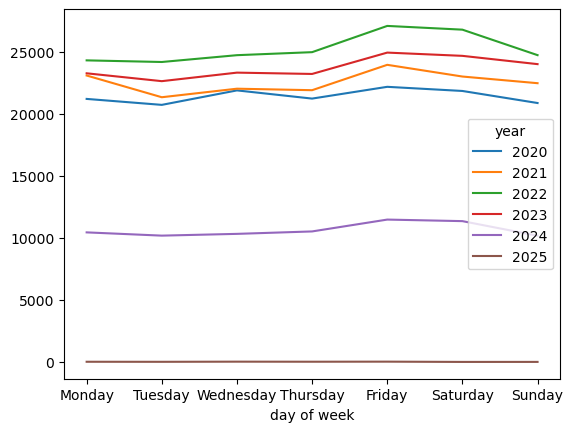

In [13]:
#количество преступлений по отдельности от дня недели в среднем год к году
week_countY = df.groupby(['year', 'day of week'], observed=False).size().unstack()
display(week_countY)
week_countY.T.plot();


тенденция ц всех годов одинакова, в будни криминал меньше, в выходные происходит рост. Пик по пятницам. Снова видно что больше всего преступлений за 2022 как и в предыдущем подпункте.В 2020 году интересный пик в среду на равне с субботой (возможно так как год был ковидный то распредление криминальной активности было по всей неделе а не только в пятницу-субботу как в 21-24 год)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2020,14618.0,13574.0,12246.0,11515.0,12498.0,12418.0,12745.0,12637.0,11838.0,12258.0,11689.0,11809.0
2021,12328.0,11407.0,12341.0,12137.0,12962.0,13046.0,14406.0,13916.0,13896.0,14423.0,13670.0,13158.0
2022,13686.0,13374.0,14841.0,14905.0,15265.0,15332.0,14987.0,15156.0,14648.0,15393.0,13952.0,15144.0
2023,14778.0,13785.0,13910.0,13408.0,13643.0,13574.0,14377.0,14280.0,13637.0,14181.0,13114.0,13266.0
2024,12717.0,11786.0,10885.0,8505.0,5141.0,3791.0,3757.0,3684.0,3797.0,3833.0,3658.0,2873.0
2025,29.0,40.0,28.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


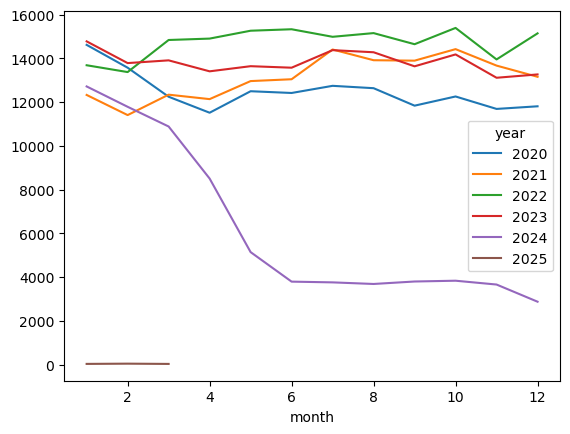

In [14]:
#О месяцв год к году
month_countY = df.groupby(['year', 'month']).size().unstack()
display(month_countY)

month_countY.T.plot();

Сильно зависимости от того какой месяц нет, так как происходят равномерно пики и снижения в течение всего года. Этот же вывод я делала когда рассматривала вест период.Снова подтвердилось что 2022 самый криминальный год,он снова выше всех. 2020 год был ковидным, поэтому как раз когда весной объявили карантины, ограничения и люди сидели дома, то происходит резкое снижение активности криминальной по сравнению с началом года, когда еще не пришла пандемия. Про 24/25 уже писала что после марта там резко становится мало данных в отличии от других годов, а в 25 так и вовсе их нет

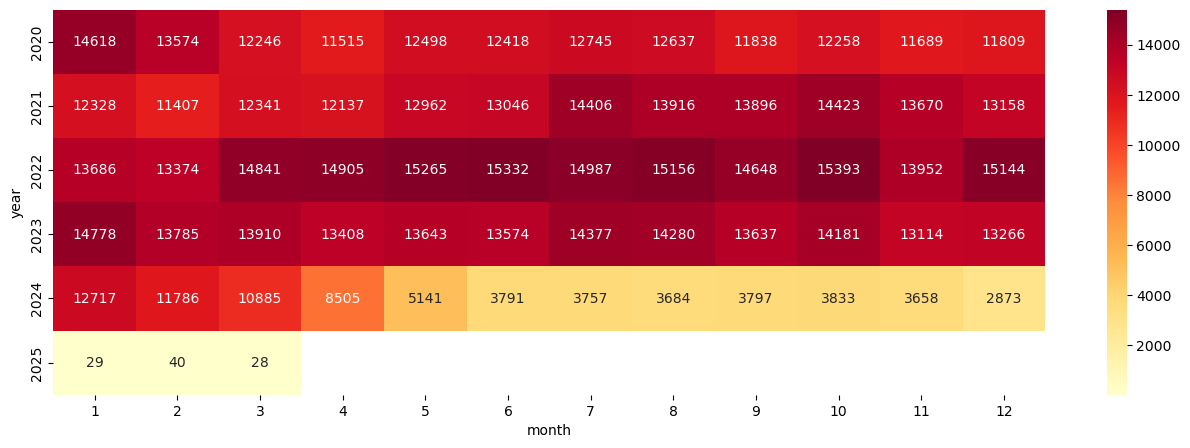

In [35]:
plt.figure(figsize=(16,5))
sns.heatmap(month_countY,annot=True,fmt='.0f',cmap='YlOrRd' );

Тепловая карта подтверждает что нет трендов по месяцам,иначе можно было бы проследить вертикальную полоску с каждогодним повышение преступной активности в каком-либо месяце. 

2022 год самый криминально активный, он самый темный

2020 сильно светлее особенно начиная с марта (ранее писала про ковид)

Про неполноту 24/отсутствие 25 писала также,тут хорошо видно это

### Финальный вывод

Рассматривая целый период я выдвигала гипотезы, когда смотрела от года к году, пришла к основным тенденциям по данным
- в зависимости от времени дня: преступления совершаются чаще всего в течение дня-вечера, когда люди наиболее активны (работа/учеба/посещение общественных мест)
- в завивимости от дня недели: лидирируют пятница и суббота (выходные). По будням ниже уровень преступности
- нет сильной зависимости от месяца, происходят сезонные пики в течение всего года

### 2. 
Проанализируйте возраст и пол жертв преступлений, есть ли взаимосвязи с местами преступлений (Premis Desc)?

In [16]:
#df['Vict Sex'].info()
df['Vict Sex'].value_counts()

Vict Sex
M    370156
F    354539
Name: count, dtype: int64

Мужчины чуть чаще являются жертвами правонарушений

count    724695.000000
mean         39.695807
std          15.483277
min           2.000000
25%          28.000000
50%          37.000000
75%          50.000000
max          98.000000
Name: Vict Age, dtype: float64

ТОП 10 возрастов жертв мужчин


Vict Age
35    12605
30    10957
31    10366
29    10317
32    10189
33    10046
28     9783
34     9724
27     9520
36     9257
Name: M, dtype: int64

ТОП 10 возрастов жертв женщин


Vict Age
30    11252
28    11097
31    10967
29    10924
32    10577
27    10528
25    10303
26    10301
33    10247
34     9632
Name: F, dtype: int64

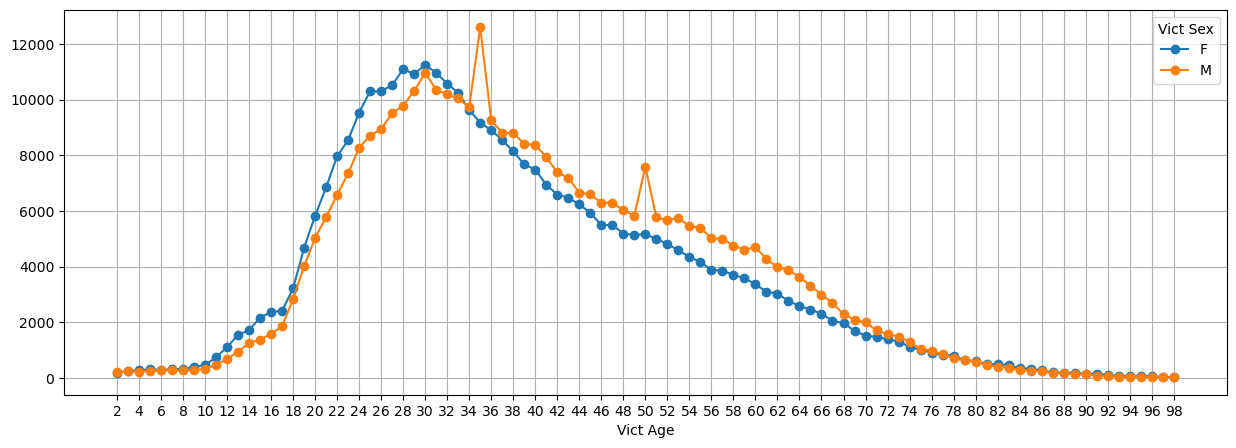

In [17]:
#df['Vict Age'].info() нет пропусков данных
#display(sorted(df['Vict Age'].unique()))
display(df['Vict Age'].describe())
d = pd.crosstab(df['Vict Sex'], df['Vict Age'])
#display(d)
d.T.plot(marker='o', figsize=(15,5));
plt.xticks(range(2,99,2));
plt.grid()

man_top10 = d.loc['M'].nlargest(10) #самые популярные возраста жертв мужчин
print('ТОП 10 возрастов жертв мужчин')
display(man_top10)

woman_top10 = d.loc['F'].nlargest(10)
print('ТОП 10 возрастов жертв женщин')
display(woman_top10)

Чаще всего жертвы возраста около 30 лет, то есть активные, работаюшие люди. Женщины чуть моложе мужчин, у них пик приходится на 30 лет, а у мужчин на 35.  У мужчин еще скачок в 50 лет. Я предполагала, что будет больше детей-подростков и более молодых девушек. Но этот возраст постепенно растет без скачков до более старшего возраста, а затем также постепенно снижается

In [ ]:
#Смотрим взаимосвязь с местами
df['Premis Desc'].info() #есть пропущенные данные 186 штук, мало, можно без вреда для данных убрать эти строки
df = df.dropna(subset=['Premis Desc'])
df['Premis Desc'].value_counts().nlargest(10)

<class 'pandas.core.series.Series'>
Index: 724509 entries, 0 to 724694
Series name: Premis Desc
Non-Null Count   Dtype 
--------------   ----- 
724509 non-null  object
dtypes: object(1)
memory usage: 11.1+ MB


Premis Desc
SINGLE FAMILY DWELLING                          159915
STREET                                          134217
MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)    112976
PARKING LOT                                      46443
SIDEWALK                                         37670
VEHICLE, PASSENGER/TRUCK                         27200
OTHER BUSINESS                                   21057
GARAGE/CARPORT                                   14658
DRIVEWAY                                         11288
OTHER RESIDENCE                                   7274
Name: count, dtype: int64

In [20]:
top10 = df['Premis Desc'].value_counts().nlargest(10).index
df_top = df[df['Premis Desc'].isin(top10)].copy()

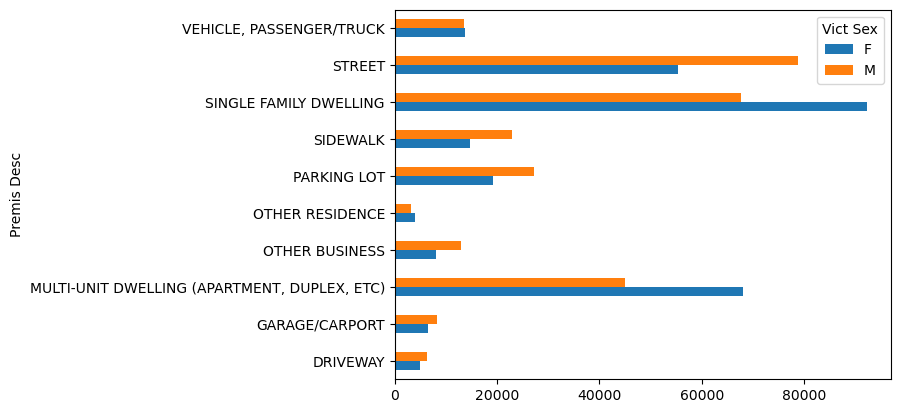

In [21]:
premis_sex = pd.crosstab(df_top['Premis Desc'], df_top['Vict Sex'])
premis_sex.plot(kind='barh');

Женщины чаще становятся жертвами преступлений в жилой среде (Single Family Dwelling и Multi-Unit Dwelling (Apartment, Duplex)), тогда как мужчины чаще сталкиваются с преступлениями в общественных местах и транспортной инфраструктуре (Street, Sidewalk, Parking Lot и тд)

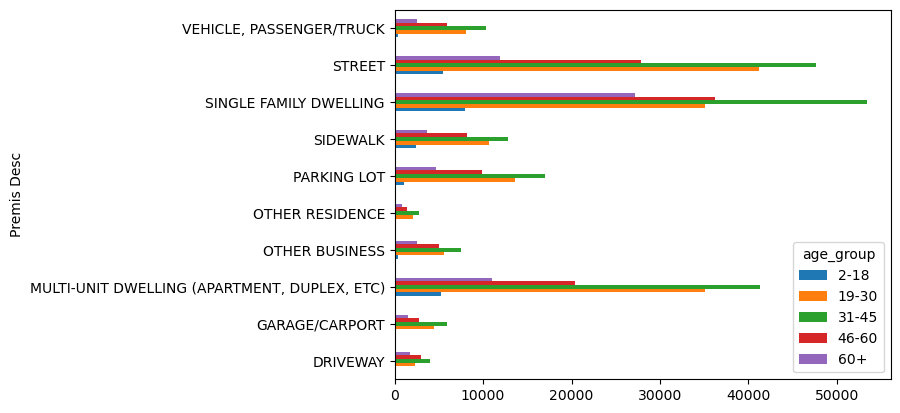

In [22]:
"""Раннее я просто смотрела возраста, но из-за большего объема таблицы для соотношения с местами совершения престулпения есть 
смысл поделить людей на возрастные группы и посмотрет как соотносится с местами """
bins = [2,18,30,45,60,100]
labels = ['2-18','19-30','31-45','46-60','60+']

df_top['age_group'] = pd.cut(df_top['Vict Age'], bins=bins, labels=labels)
premis_age = pd.crosstab(df_top['Premis Desc'], df_top['age_group'])

premis_age.plot(kind='barh');

Наибольшее количество преступлений практически во всех категориях приходится на возрастную группу 31–45 лет (что подтверждает анализ возраста отдельно, где я подвела итог, что чаще всего возраст жертв примернок как раз 30 лет и окло того) - самый уязвимый возраст

Возрастная группа 19–30 лет также демонстрирует высокий уровень попадания в такие ситуации в качестве жертв, особенно в общественных местах, на улицах и парковках

Дети и подростки (2–18 лет) реже становятся жертвами преступлений во всех рассматриваемых категориях. Аналогично, относительно низкие показатели наблюдаются для группы 60+, хотя в жилых помещениях их доля остается заметной.

### 3. 
Как меняется количественно преступлений в зависимости от района (AREA NAME) и места преступления (Premis Desc) год к году.

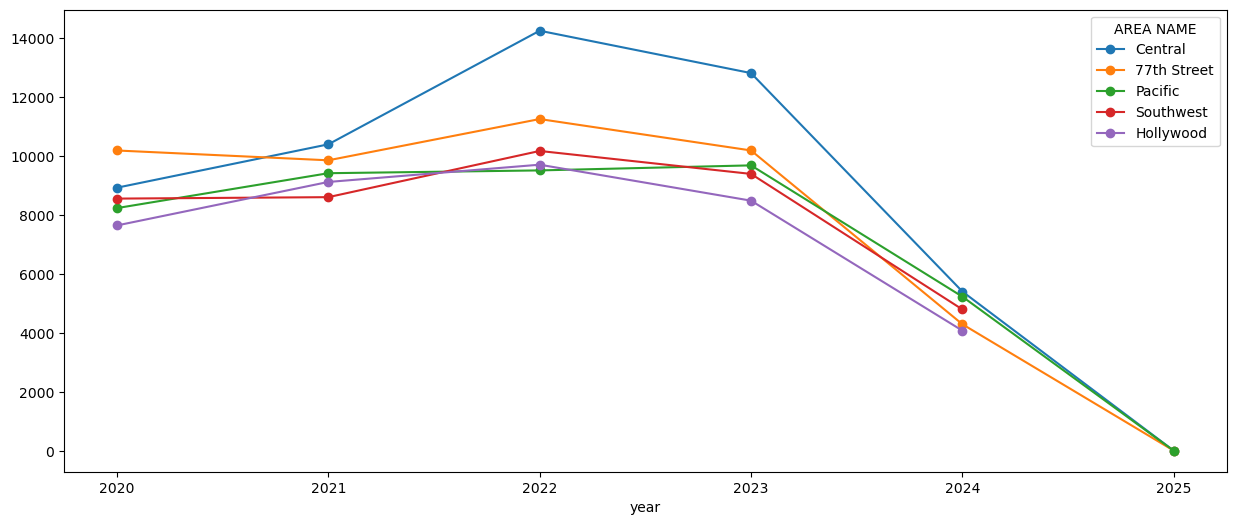

In [37]:
#df['AREA NAME'].info() после очистки na в 2 задание, здесь нет na

area_year = df.groupby(['year', 'AREA NAME']).size().unstack()
#display(df['AREA NAME'].value_counts().nlargest(10))
top_areas = df['AREA NAME'].value_counts().nlargest(5).index #10 районов оказалось слишком много, начиная с 5-6 они примерно одинаковые, поэтому беру 5
m = area_year[top_areas] #посмотреть топ 10 районов с большим количеством преступлений
m.plot(marker='o', figsize=(15,6));

Снова наблюдаем, что для всех районов 2022 самый криминальный, он является пиком для всех линий

Central - самый частый по преступлениям районам (так как самый часто посещаемый особенно туристами, плюс множество общественных пространств, тц, офисов и других заведний которые все посещают), и не дальше ушла 77 улица

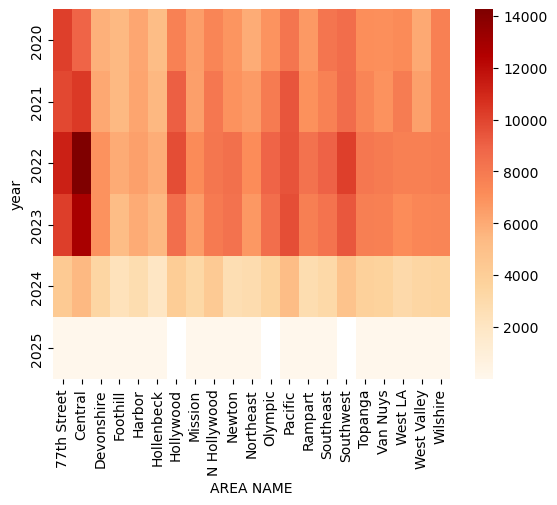

In [25]:
sns.heatmap(area_year, cmap='OrRd');

На тепловой карте видно одни из самых редких районов для преступлений - Footthill, harbor, hollenbeck

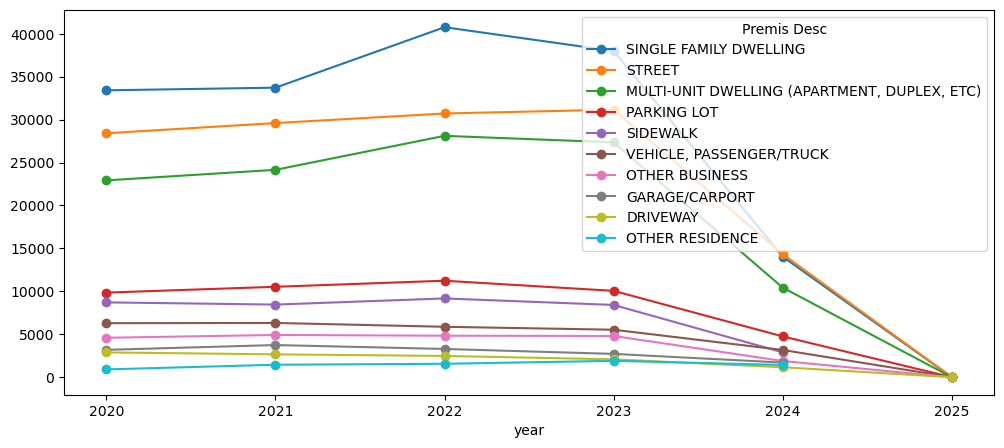

In [27]:
premis_year = df.groupby(['year', 'Premis Desc']).size().unstack()
top_premis = df['Premis Desc'].value_counts().nlargest(10).index

premis_year[top_premis].plot(figsize=(12,5), marker='o');

Семейные дома/квартиры, вообще обычная жилплоащдь самая популярная (в 6 вопросе хочу посмотреть почему, с оружием соотнести)

Затем улицы и только потом разные апартаменты, многожилищные комплексы/дома, дальше остальное примерно на одном уровне

снова если и наблюдаются пики то в 2022, но не значительные (для singly family dwelling, multi-unit dwelling)

### 4. 
Визуализируйте транспортные правонарушения (VEHICLE) на географической карте.

ШИрота (LAT): 33.7 – 34.4
Долгота (LON): -118.7 – -118.1 примерно подтверждается .describe()

In [28]:
display(df[['LAT','LON']].describe())

,LAT,LON
count,724509.000000,724509.000000
mean,33.997330,-118.083288
std,1.642736,5.693777
min,0.000000,-118.667600
25%,34.015500,-118.434800
50%,34.059800,-118.326600
75%,34.167000,-118.275500
max,34.334300,0.000000


In [ ]:
#https://www.google.com/search?client=safari&rls=en&q=px.density_map&ie=UTF-8&oe=UTF-8 документация
vehicle = df[df['Premis Desc'].str.contains('VEHICLE', case=False)]
vehicle = vehicle[(vehicle['LAT'].notna()) & (vehicle['LON'].notna()) & (vehicle['LAT'] != 0) & (vehicle['LON'] != 0)]

fig = px.density_map(vehicle, lat='LAT', lon='LON', radius=4, 
                     center=dict(lat=vehicle['LAT'].mean(), lon=vehicle['LON'].mean()), map_style='open-street-map'
                     )
fig.show()

Очеыидно что в центральной части ЛА самый яркий очаг, так как больше всего преступлений в самоц оижвленной части города (приблизить например Downtown, financial district,south park. Вокруг этих районов как раз концетрация точек с vechile происшествиями)
Также очень хорошо видно что в соновном точки двигаются вдоль различных дорог и магистралей + мноэество парковок (прямо при увеличение видно какие преступления совершены на дороге/какие на парковке).  Спускаяь ниже идет дорога к юной набережной ЛА и видно как точки идут вертикальной полоской вниз (как раз вдоль дороги)

### 5. 
Нанесите на карту самые проблемные перекрестки дорог (Cross Street)

<class 'pandas.core.series.Series'>
Index: 724509 entries, 0 to 724694
Series name: Cross Street
Non-Null Count   Dtype 
--------------   ----- 
113123 non-null  object
dtypes: object(1)
memory usage: 11.1+ MB


Cross Street
BROADWAY                              1827
FIGUEROA                     ST       1477
VERMONT                      AV       1252
FIGUEROA                              1246
SAN PEDRO                             1158
                                      ... 
ARTESIAN                     PL          1
78TH                                     1
CAROL                        PL          1
E  98TH                         ST       1
SUMMERLAND                   ST          1
Name: count, Length: 8892, dtype: int64

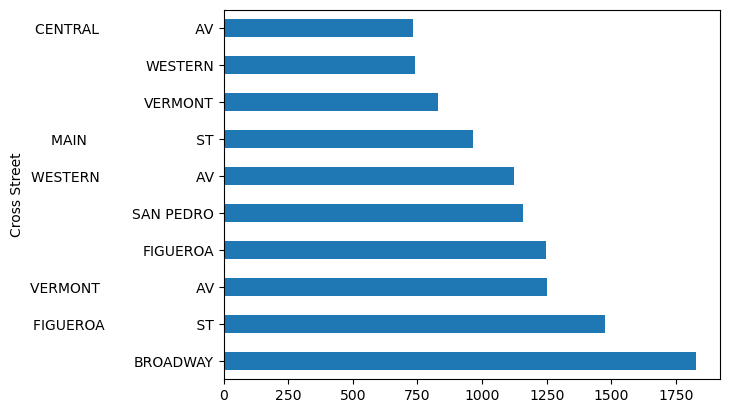

In [47]:
df['Cross Street'].info() #не NA только 113123 стркои
cross_counts = df['Cross Street'].dropna().value_counts()
display(cross_counts)
#попробовала 20, с 7 значения уже ниже 1000 преступлений и дальше ниже, можно и 10 для наглядности графика
cross_counts.nlargest(10).plot(kind='barh');

In [55]:
top_cross = cross_counts.nlargest(10).index #Если забить .nsmallest()то они будут очень отдалены от центральной части ЛА,появится точка на береговой южной части и сверху на севере в West Hollywood

cross_df = df[df['Cross Street'].isin(top_cross)]
cross_df = cross_df[(cross_df['LAT'].notna()) & (cross_df['LON'].notna()) & (cross_df['LAT'] != 0) & (cross_df['LON'] != 0)]
cross_map = cross_df.groupby('Cross Street').agg(crimes=('Cross Street', 'size'), lat=('LAT', 'mean'), lon=('LON', 'mean')).reset_index()

fig = px.scatter_map(cross_map, lat='lat', lon='lon', size='crimes', hover_name='Cross Street', hover_data=['crimes'])
fig.update_layout(map_style='open-street-map')


Конечно же основные проблемные перекрестки в центральной части штата. БОльше всего в Бродвее

Единичные происшествия на перекрестках в основном отдаленных от центральной части ЛА (не стала выводить bottom рейтинг, потому что надо посмотреть наиболее проблемные участки, но мне было интересно посмотреть безопасные и они на окраинах штата некоторые)

In [58]:
#cross_counts.nsmallest(5)

### 6. 
Разделите преступления на категории по вами предложенному принципу. Обоснуйте решение. Есть ли какие либо закономерности по группам преступлений? Можно ли это визуализировать на карте?

Я решила смотреть по жизнено логическому приниципу (опаснее дома/на улице/в заведениях и тд)

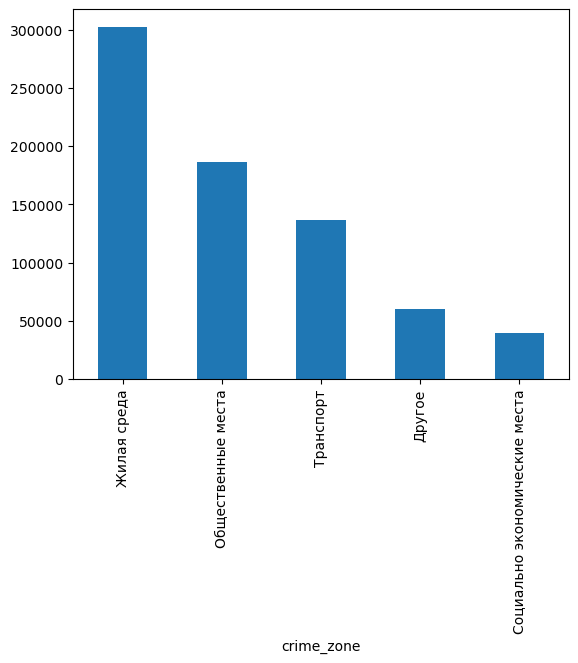

In [32]:
#display(df['Premis Desc'].unique()) посмотрела какие примерно места, чтобы выделить ключевые слова для классификации
def crime_zone(place):
    place = str(place).upper()
    # Жилая среда
    if any(x in place for x in [
        'DWELLING',
        'APARTMENT',
        'CONDOMINIUM',
        'HOUSE',
        'RESIDENCE',
        'PORCH',
        'DRIVEWAY'
    ]):
        return 'Жилая среда'
    # Транспорт
    elif any(x in place for x in [
        'VEHICLE',
        'PARKING',
        'GARAGE',
        'CARPORT',
        'BUS',
        'MTA',
        'TRAIN',
        'STATION',
        'GAS STATION',
        'VALET'
    ]):
        return 'Транспорт'
    # Коммерческие объекты
    elif any(x in place for x in [
        'STORE',
        'MARKET',
        'BUSINESS',
        'RESTAURANT',
        'COFFEE',
        'PHARMACY',
        'DRUG STORE',
        'SALON',
        'HOTEL',
        'MOTEL',
        'OFFICE',
        'MINI-MART'
    ]):
        return 'Социально экономические места'
    # Общественные пространства
    elif any(x in place for x in [
        'STREET',
        'SIDEWALK',
        'ALLEY',
        'PARK',
        'PLAYGROUND',
        'OTHER/OUTSIDE',
        'BUS STOP'
    ]):
        return 'Общественные места'
    # Гос учреждения
    #elif any(x in place for x in ['SCHOOL','COLLEGE','UNIVERSITY','GOVERNMENT','DAY CARE', 'NURSING', 'SHELTER']): return 'ОБразование/медицина и тд' 
    # #Их в итоге мало очень, можно отнести в другое
    else:
        return 'Другое'

df['crime_zone'] = df['Premis Desc'].apply(crime_zone)
zone_counts = df['crime_zone'].value_counts()

zone_counts.plot(kind='bar');

Больше всего преступлений в жилых помещениях (предполагаю различные кражи, взломы и тд). Стереотип о La и США в целом реально подтверждаются, что много мошенников, бомжей, воришек

In [ ]:
map_df = df[(df['LAT'] != 0) & (df['LON'] != 0)].sample(5000) #берем случайные, чтобы из-за количества точек не выполнялся долго код и было хорошо видно закономерности на карте
fig = px.scatter_map(map_df, lat='LAT', lon='LON', color='crime_zone', hover_data=['Premis Desc', 'AREA NAME'])

fig.update_layout(mapbox_style='open-street-map')

Зеленого больше всего - в жилых помещениях чаще всего совершаются правонарушения - прямо очагами в центральной части, чуть меньше в северной.Также
видно много общественных также мест

Хоть и на диаграмме выше показывается,что социально экономических мест (по типу ресторанов/аптек/кафе) сильно меньше, но хорошо видно что их высокая концетрация именно в центральной части (как раз Central - самая часто посещаемая для туристов и различных бизнесменов).Транспортных преступлений в этой части также много, красные точки возле оранжевых

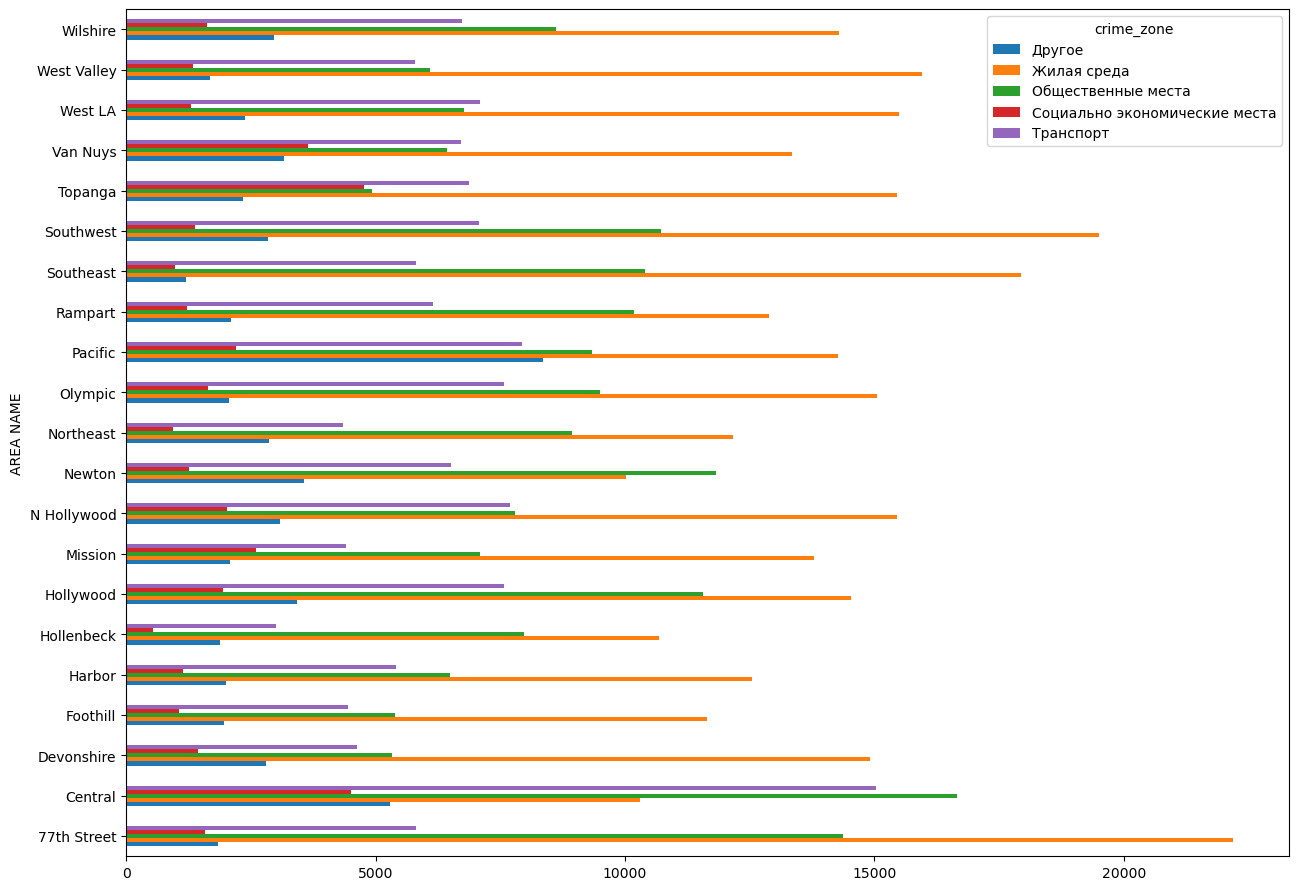

In [ ]:
pd.crosstab(df['AREA NAME'], df['crime_zone']).plot(kind='barh', figsize=(15,11)); #отображу графиком,лучше в глаза бросается особенность с 77 улицей

В основном оранжевая полоска везде лидирует - то есть действительно лидер "Жилая среда"
НО! Интереное наблюдение в Central area лидирует "Общественные места" (улица/парки),потом траснпортные чп и только затем жилые помещения.ЭТо подтверждает что Центральный район более туристический (так как извесьтный) и также бизнессовый, поэтому здесь жилые дома лишь на 3 месте по частоте

а еще снова замечаем,что 77th street часто мелькает как самая криминальная улица (https://www.greghillassociates.com/lapd-77th-precinct-station.html) - и вправду не лучшее место погулять, приехав в Лос Анджелес

## НА последок оставила проверить взаимосвязь premis desc и weapon 
Идея из 3 вопроса. Изначально я думала для 6 сделать классификацию преступлений в целом по столбцу weapon, но там достаточно много пропущенных данных

Index(['SINGLE FAMILY DWELLING', 'STREET',
       'MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)', 'PARKING LOT',
       'SIDEWALK', 'VEHICLE, PASSENGER/TRUCK', 'OTHER BUSINESS',
       'GARAGE/CARPORT', 'DRIVEWAY', 'OTHER RESIDENCE'],
      dtype='object', name='Premis Desc')

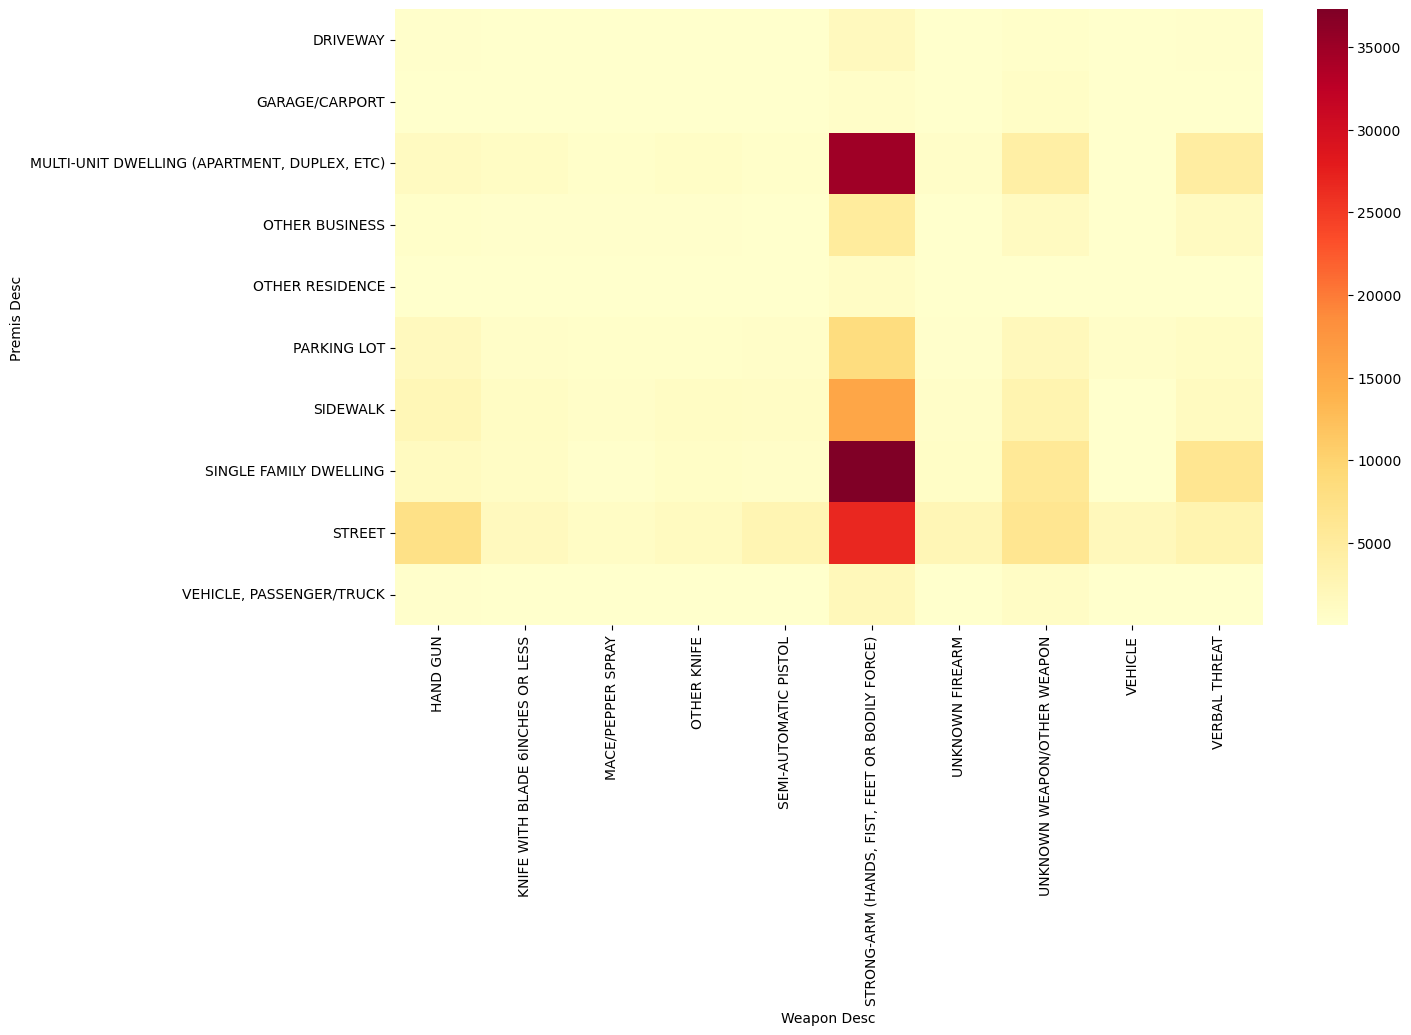

In [ ]:
#хотела посмотреть по топ 10 оружий и топ 10 premis desc 
#display(top_premis)
top_weapon = df['Weapon Desc'].value_counts().nlargest(10).index
weapon_premis = pd.crosstab(
    df[df['Premis Desc'].isin(top_premis)]['Premis Desc'],
    df[df['Weapon Desc'].isin(top_weapon)]['Weapon Desc']
)

plt.figure(figsize=(14,8))
sns.heatmap(weapon_premis, cmap='YlOrRd')
plt.show()

Так как мало заполнено данных об оружие, то особо никаких тенденций и не увидишь

Единственное, что кулаки самые популярные, особенно в жилых помещениях,и чуть мелькает вербальные угрозы
На улице мелькает ручной пистолет

In [75]:
df['Weapon Desc'].info()

<class 'pandas.core.series.Series'>
Index: 724509 entries, 0 to 724694
Series name: Weapon Desc
Non-Null Count   Dtype 
--------------   ----- 
298031 non-null  object
dtypes: object(1)
memory usage: 27.2+ MB


Теперь понятно почему ячейка с кулаками темно красная, она составляет 164к от 298к всего всех оружий.Уберу вариант с arm,чтобы посмотреть картину по другим оружиям

In [78]:
df['Weapon Desc'].value_counts().head(20)

Weapon Desc
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    164790
UNKNOWN WEAPON/OTHER WEAPON                        31192
VERBAL THREAT                                      21994
HAND GUN                                           17073
KNIFE WITH BLADE 6INCHES OR LESS                    6381
SEMI-AUTOMATIC PISTOL                               6089
OTHER KNIFE                                         5453
UNKNOWN FIREARM                                     5024
MACE/PEPPER SPRAY                                   3415
VEHICLE                                             2917
PIPE/METAL PIPE                                     2220
BOTTLE                                              2183
STICK                                               2124
ROCK/THROWN OBJECT                                  2108
FOLDING KNIFE                                       2094
CLUB/BAT                                            1995
KITCHEN KNIFE                                       1826
AIR PISTOL/REVOLVER

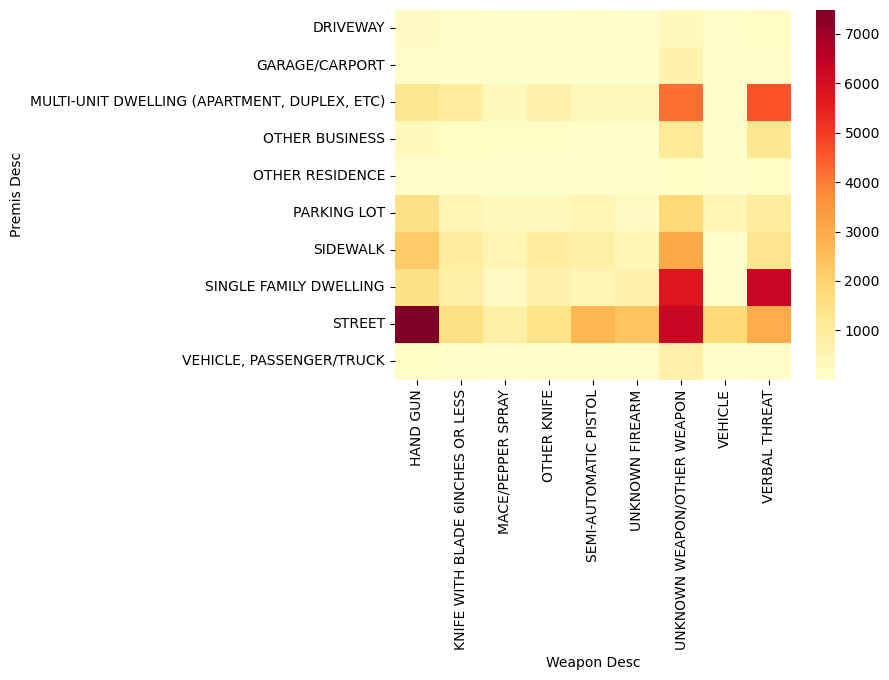

In [83]:
weapon_premis = weapon_premis.drop(
    [c for c in weapon_premis.columns if 'FORCE' in c]
)
sns.heatmap(weapon_premis, cmap='YlOrRd');

> Наибольшее количество преступлений с использованием огнестрельного оружия (HAND GUN, SEMI-AUTOMATIC PISTOL) совершается на улицах (STREET).

> В жилых помещениях (SINGLE FAMILY DWELLING и MULTI-UNIT DWELLING) заметно чаще встречаются случаи угроз (VERBAL THREAT) и преступлений с неустановленным оружием (UNKNOWN WEAPON/OTHER)

> На парковках (PARKING LOT) и тротуарах (SIDEWALK) также наблюдается относительно высокая частота использования огнестрельного оружия и ножей, однако значительно ниже, чем на улицах


Таким образом, тип используемого оружия связан с местом совершения преступления. На открытых общественных территориях чаще встречается применение огнестрельного оружия, тогда как в жилой среде более распространены угрозы и конфликты без явного применения оружия.

Когда я хотела проверить соотношение оружия с местом, то я ожидала такого результата, но оказалось, что сначала идут на 1 местк по частоте кулаки, а затем: самой заметной ячейкой на тепловой карте является сочетание STREET × HAND GUN, что указывает на особенно высокую распространённость преступлений с использованием пистолетов на улицах города.
